## Classificatore Real+Augmented — MaxViT-Tiny-512

Il notebook implementa un classificatore **MaxViT-Tiny-512** (`timm`) addestrato su un dataset arricchito con **data augmentation tradizionale**.
Equivalente MaxViT-512 di [`10_Classificatore_Real_Augmented_ResNet-50_FineTuned.ipynb`](10_Classificatore_Real_Augmented_ResNet-50_FineTuned.ipynb), usato per la Domanda di Ricerca D3
(sostenibilità: confrontato con l'altra configurazione nel notebook `20_Confronto_Classificatori_MaxViT512.ipynb`).

### Composizione dataset
*   **Train set:** Immagini originali reali (classi `0` e `1` da `data/processed/train/`) **+** campioni positivi augmentati tradizionalmente (`data/real_augmented/`).
*   **Validation / Test set:** Sole immagini originali reali (`data/processed/`).

In [8]:
# === Bootstrap unificato notebooks/ ===
# Funziona dalla root del progetto e da ogni sottocartella della struttura notebooks/.
import sys as _sys
from pathlib import Path as _Path


def _find_mammo_root():
    for _candidate in [_Path.cwd().resolve(), *_Path.cwd().resolve().parents]:
        if _candidate.name == "MammoDiffusion":
            return _candidate
        if (_candidate / "data").is_dir() and (_candidate / "notebooks").is_dir():
            return _candidate
    raise FileNotFoundError("Root MammoDiffusion non trovata da " + str(_Path.cwd()))


PROJECT_ROOT = _find_mammo_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
UTILITY_DIR = NOTEBOOKS_DIR / "utility"
for _path in (str(UTILITY_DIR), str(NOTEBOOKS_DIR)):
    if _path not in _sys.path:
        _sys.path.insert(0, _path)

BASE = PROJECT_ROOT
BASE_DIR = PROJECT_ROOT
BASE_PATH = str(PROJECT_ROOT) + "/"
# === Fine bootstrap unificato ===

import os
import sys

# Controlla se il notebook sta girando su Google Colab
# [notebooks bootstrap] Il blocco Colab/local originale e' stato
# neutralizzato: BASE_PATH e BASE sono gia' definiti dal bootstrap
# unificato in cima al notebook.
print(f"Percorso base: ", BASE_PATH)

Ambiente locale rilevato.
Percorso base:  ../


In [ ]:
# CLASSIFIER_PHASE_MODES_V1
TRAIN_MODE = "auto"       # auto | run | skip
VALIDATION_MODE = "auto"  # auto | run | skip | recompute
LOCKED_TEST_MODE = "manual"
from classifier_phase_planner import classifier_plan
CLASSIFIER_PLAN = classifier_plan(PROJECT_ROOT, PROJECT_ROOT / 'notebooks/3_classifiers/02e_MaxViT512_RealAugmented.ipynb', TRAIN_MODE, VALIDATION_MODE, LOCKED_TEST_MODE)
print(CLASSIFIER_PLAN)


#### Import Librerie

In [9]:
import zipfile
from pathlib import Path
import gdown
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from datetime import date
from sklearn.metrics import (confusion_matrix, roc_curve, classification_report,
                              roc_auc_score, precision_score, recall_score, f1_score)

sys.path.insert(0, os.getcwd())
from maxvit_utils import (
    MODEL_NAME, build_maxvit_model, resolve_normalization, make_dataloader,
    freeze_all, unfreeze_head, unfreeze_stages_from, unfreeze_all, count_trainable_params,
    BinaryFocalLoss, compute_pos_weight, EarlyStopping, ModelCheckpoint, CSVLogger,
    fit, predict_probs, optimal_threshold_youden, make_gradcam_heatmap, show_gradcam,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


#### Verifica presenza dataset preprocessato

Verifica se il dataset preprocessato è già presente in locale (CSV + immagini). Se non lo trova, scarica il file `.zip` da Google Drive tramite `gdown`, lo estrae nella cartella `data/processed/` e rimuove l'archivio.

In [10]:
# ID del file su Google Drive (stesso dataset preprocessato usato dai classificatori ResNet-50)
PROCESSED_DRIVE_ID = "1qQral_BIBlMl0QN3PllJukdYTOmNGWr3"
PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')

TRAIN_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "train.csv")
VAL_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "val.csv")

def processed_data_ready():
    if not os.path.isfile(TRAIN_CSV_PATH) or not os.path.isfile(VAL_CSV_PATH):
        return False
    try:
        first_path = pd.read_csv(TRAIN_CSV_PATH)['processed_path'].iloc[0]
        return os.path.isfile(os.path.join(BASE_PATH, first_path))
    except Exception:
        return False

if not processed_data_ready():
    print("Dataset non trovato, scarico da Google Drive...")
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))
    os.remove(PROCESSED_ZIP)
    print(f"Dataset estratto in: {os.path.join(BASE_PATH, 'data')}")
else:
    print("Dataset già presente, salto il download")

Dataset già presente, salto il download


#### Verifica presenza dati augmentati (notebook 02)

Le immagini augmentate tradizionalmente (`data/real_augmented/`) sono prodotte dal notebook
[`02_Data_Augmentation_Trad.ipynb`](02_Data_Augmentation_Trad.ipynb) e non sono ridistribuite separatamente
su Google Drive: se mancanti, eseguire prima quel notebook.

In [11]:
DIR_AUG = os.path.join(BASE_PATH, 'data', 'real_augmented')
assert os.path.isdir(DIR_AUG) and any(Path(DIR_AUG).glob('*.png')), (
    f"Cartella '{DIR_AUG}' mancante o vuota. Esegui prima il notebook 02_Data_Augmentation_Trad.ipynb."
)

import re
_LABEL_RE = re.compile(r"_label([01])")

def carica_dati_augmented(dirpath):
    paths, labels = [], []
    for p in sorted(Path(dirpath).glob("*.png")):
        m = _LABEL_RE.search(p.name)
        if m is None:
            continue
        paths.append(str(p)); labels.append(int(m.group(1)))
    return paths, labels

extra_paths, extra_labels = carica_dati_augmented(DIR_AUG)
print(f"Immagini augmentate trovate: {len(extra_paths)}")

Immagini augmentate trovate: 1020


#### Configurazione

In [12]:
# Cartella esperimento
OUTPUT_DIR = os.path.join(BASE_PATH, 'experiments', 'classifiers/maxvit512/02e_real_augmented')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(OUTPUT_DIR)

../experiments/exp_maxvit512_real_augmented


#### Configurazione

In [13]:
IMG_SIZE = 512          # input nativo di maxvit_tiny_tf_512
BATCH_SIZE = 8          # ridotto rispetto a ResNet-50 (224x224): 512x512 su MaxViT richiede piu' VRAM
SEED = 42

# Normalizzazione attesa per maxvit_tiny_tf_512.in1k (verificata a runtime dopo la costruzione del modello)
IMAGENET_MEAN = (0.5, 0.5, 0.5)
IMAGENET_STD = (0.5, 0.5, 0.5)

torch.manual_seed(SEED)
np.random.seed(SEED)
print(TRAIN_CSV_PATH)
print(VAL_CSV_PATH)

../data/processed/metadata/train.csv
../data/processed/metadata/val.csv


#### Costruzione dei subset per l'addestramento

In [14]:
def carica_dati_real(base_dir, classi=("0", "1")):
    paths, labels = [], []
    for c in classi:
        for p in sorted(Path(base_dir).joinpath(c).glob("*.png")):
            paths.append(str(p)); labels.append(int(c))
    return paths, labels

def count(nome, paths, labels):
    labels = np.array(labels)
    print("%-6s tot=%5d | sano(0)=%5d | malato(1)=%5d" % (nome, len(labels), int((labels==0).sum()), int((labels==1).sum())))

DIR_TRAIN = os.path.join(BASE_PATH, 'data', 'processed', 'train')
DIR_VAL   = os.path.join(BASE_PATH, 'data', 'processed', 'val')
DIR_TEST  = os.path.join(BASE_PATH, 'data', 'processed', 'test')

real_tr_p, real_tr_y = carica_dati_real(DIR_TRAIN)
train_p = real_tr_p + extra_paths
train_y = real_tr_y + extra_labels
val_p, val_y = carica_dati_real(DIR_VAL)
test_p, test_y = carica_dati_real(DIR_TEST)

config_name = 'Real+Augmented'
source_label = 'augmentati positivi'

print(f"[{config_name}] reali train={len(real_tr_y)} + {source_label}={len(extra_labels)}")
count("TRAIN", train_p, train_y)
count("VAL", val_p, val_y)
count("TEST", test_p, test_y)

df_train = pd.DataFrame({'processed_path': train_p, 'cancer': train_y})
df_val   = pd.DataFrame({'processed_path': val_p,   'cancer': val_y})
df_test  = pd.DataFrame({'processed_path': test_p,  'cancer': test_y})

[Real+Augmented] reali train=2041 + augmentati positivi=1020
TRAIN  tot= 3061 | sano(0)= 1701 | malato(1)= 1360
VAL    tot=  437 | sano(0)=  364 | malato(1)=   73
TEST   tot=  438 | sano(0)=  365 | malato(1)=   73


#### Preparazione Dataset e Pipeline di Input

Costruisce i `DataLoader` PyTorch di train/validation. Preprocessing applicato ad ogni immagine:
decodifica in scala di grigi, resize a 512×512, replica su 3 canali, normalizzazione (mean=std=0.5).
Augmentation (opzionale, disabilitata di default): flip orizzontale e variazione di luminosità —
stesse scelte del progetto ResNet-50 (niente rotazioni/zoom per non introdurre artefatti irrealistici).

In [15]:
train_loader = make_dataloader(
    df_train, 'processed_path', 'cancer', IMAGENET_MEAN, IMAGENET_STD, IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=True, augment=False, seed=SEED,
)
val_loader = make_dataloader(
    df_val, 'processed_path', 'cancer', IMAGENET_MEAN, IMAGENET_STD, IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=False,
)

n_pos = int((df_train['cancer'] == 1).sum())
n_neg = int((df_train['cancer'] == 0).sum())
print(f"Train: {len(df_train)} immagini (cancer=1: {n_pos}, cancer=0: {n_neg})")
print(f"Val:   {len(df_val)} immagini")

Train: 3061 immagini (cancer=1: 1360, cancer=0: 1701)
Val:   437 immagini


In [16]:
test_loader = make_dataloader(df_test, 'processed_path', 'cancer', IMAGENET_MEAN, IMAGENET_STD, IMG_SIZE,
                               batch_size=BATCH_SIZE, shuffle=False)

#### Configurazione e Salvataggio dell'Esperimento

In [17]:
experiment_config = {
    "experiment_name": os.path.basename(OUTPUT_DIR),
    "date": date.today().isoformat(),
    "backbone": {
        "name": "maxvit_tiny_tf_512.in1k",
        "library": "timm",
        "weights": "in1k",
        "input_shape": [IMG_SIZE, IMG_SIZE, 3],
    },
    "head": {
        "type": "timm NormMlpClassifierHead",
        "pooling": "avg",
        "pre_logits": "Linear(512) + Tanh",
        "dropout": 0.0,
        "output": "Linear(1) [logits, BCEWithLogitsLoss]",
    },
    "preprocessing": {
        "img_size": [IMG_SIZE, IMG_SIZE],
        "normalization": "mean=std=0.5 (timm in1k tf-style)",
    },
    "data": {
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "augmentation": False,
        "config": "Real+Augmented",
    },
    "phase1_head_training": {
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "loss": "BCEWithLogitsLoss(pos_weight=balanced)",
        "max_epochs": 25,
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 7,
        "backbone_trainable": False,
    },
    "phase2_fine_tuning": {
        "optimizer": "Adam",
        "learning_rate": 1e-5,
        "loss": "BinaryFocalLoss(alpha=0.75, gamma=2.0)",
        "max_epochs": 30,
        "fine_tune_from": "stage 3/4 (ultimo stage)",
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 5,
        "early_stopping_min_delta": 1e-3,
        "reduce_lr_factor": 0.5,
        "reduce_lr_patience": 3,
        "min_lr": 1e-7,
    },
}

config_path = os.path.join(OUTPUT_DIR, 'experiment_config.json')
with open(config_path, 'w') as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)
print(f"Configurazione esperimento salvata in: {config_path}")

Configurazione esperimento salvata in: ../experiments/exp_maxvit512_real_augmented/experiment_config.json


#### Costruzione del Modello — Fase 1 (Head Training)

Backbone **MaxViT-Tiny-512** (`timm`, pre-addestrato `in1k`, input 512×512 RGB) con testa di classificazione
binaria integrata in timm (`NormMlpClassifierHead`: pooling → LayerNorm → Linear(512) → Tanh → Dropout → Linear(1)).

Fase 1: backbone (stem + 4 stage) completamente congelato, si addestra solo `model.head`.
`BCEWithLogitsLoss` con `pos_weight` bilanciato equivale al `class_weight='balanced'` usato per ResNet-50.

In [18]:
model = build_maxvit_model(num_classes=1, pretrained=True)
model.to(DEVICE)

resolved_mean, resolved_std, resolved_size = resolve_normalization(model)
assert resolved_size == IMG_SIZE, f"IMG_SIZE atteso {resolved_size}, trovato {IMG_SIZE}"
print(f"Normalizzazione modello: mean={resolved_mean}  std={resolved_std}  input_size={resolved_size}")

freeze_all(model)
unfreeze_head(model)
trainable, total = count_trainable_params(model)
print(f"Parametri trainable (Fase 1): {trainable:,} / {total:,}")

Normalizzazione modello: mean=(0.5, 0.5, 0.5)  std=(0.5, 0.5, 0.5)  input_size=512
Parametri trainable (Fase 1): 264,193 / 30,537,097


#### Training in 2 Fasi

**Fase 1** — backbone congelato, si addestra solo `model.head` con `BCEWithLogitsLoss` (pos_weight bilanciato).
**Fase 2** — si sblocca lo stage 3/4 di MaxViT con `BinaryFocalLoss` (γ=2, α=0.75) e LR ridotto,
analogamente alle altre configurazioni ResNet-50 del progetto.

In [19]:
pos_weight = compute_pos_weight(df_train['cancer'].values).to(DEVICE)
criterion_fase1 = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_fase1 = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=1e-3
)

early_stop_fase1 = EarlyStopping(patience=7, mode='max', restore_best_weights=True)
checkpoint_fase1 = ModelCheckpoint(os.path.join(OUTPUT_DIR, 'real_augmented_maxvit512_fase1_best.pt'), mode='max')
csv_logger_fase1 = CSVLogger(os.path.join(OUTPUT_DIR, 'training_log_fase1.csv'))

history_phase1 = fit(
    model, train_loader, val_loader, optimizer_fase1, criterion_fase1,
    epochs=25, device=DEVICE,
    early_stopping=early_stop_fase1, checkpoint=checkpoint_fase1, csv_logger=csv_logger_fase1,
)

Epoch 1/25 - loss: 0.6944 - auc: 0.7129 - val_loss: 0.5491 - val_auc: 0.6238
Epoch 2/25 - loss: 0.5540 - auc: 0.8391 - val_loss: 0.5385 - val_auc: 0.6383
Epoch 3/25 - loss: 0.4948 - auc: 0.8739 - val_loss: 0.5686 - val_auc: 0.6194
Epoch 4/25 - loss: 0.4145 - auc: 0.9141 - val_loss: 0.6284 - val_auc: 0.6241
Epoch 5/25 - loss: 0.3730 - auc: 0.9297 - val_loss: 0.6008 - val_auc: 0.6288
Epoch 6/25 - loss: 0.3100 - auc: 0.9528 - val_loss: 0.6494 - val_auc: 0.5908
Epoch 7/25 - loss: 0.2563 - auc: 0.9696 - val_loss: 0.6979 - val_auc: 0.6276
Epoch 8/25 - loss: 0.2121 - auc: 0.9804 - val_loss: 0.6882 - val_auc: 0.6199
Epoch 9/25 - loss: 0.1634 - auc: 0.9893 - val_loss: 0.7864 - val_auc: 0.5903
Early stopping all'epoca 9 (best val_auc=0.6383)


In [20]:
unfreeze_stages_from(model, start_stage=3)
trainable, total = count_trainable_params(model)
print(f"Parametri trainable (Fase 2): {trainable:,} / {total:,}")

criterion_fase2 = BinaryFocalLoss(alpha=0.75, gamma=2.0)
optimizer_fase2 = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=1e-5
)
lr_scheduler_fase2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fase2, mode='max', factor=0.5, patience=3, min_lr=1e-7
)

early_stop_fase2 = EarlyStopping(patience=5, min_delta=1e-3, mode='max', restore_best_weights=True)
checkpoint_fase2 = ModelCheckpoint(os.path.join(OUTPUT_DIR, 'real_augmented_maxvit512_final_best.pt'), mode='max')
csv_logger_fase2 = CSVLogger(os.path.join(OUTPUT_DIR, 'training_log_fase2.csv'))

history_phase2 = fit(
    model, train_loader, val_loader, optimizer_fase2, criterion_fase2,
    epochs=30, device=DEVICE,
    early_stopping=early_stop_fase2, checkpoint=checkpoint_fase2, csv_logger=csv_logger_fase2,
    lr_scheduler=lr_scheduler_fase2,
)

print(f"\nTraining completato. Il miglior modello e' salvato in: {os.path.join(OUTPUT_DIR, 'real_augmented_maxvit512_final_best.pt')}")

Parametri trainable (Fase 2): 17,845,569 / 30,537,097
Epoch 1/30 - loss: 0.0509 - auc: 0.9095 - val_loss: 0.0781 - val_auc: 0.6230
Epoch 2/30 - loss: 0.0289 - auc: 0.9582 - val_loss: 0.0862 - val_auc: 0.6248
Epoch 3/30 - loss: 0.0224 - auc: 0.9763 - val_loss: 0.0876 - val_auc: 0.6178
Epoch 4/30 - loss: 0.0158 - auc: 0.9902 - val_loss: 0.1068 - val_auc: 0.6191
Epoch 5/30 - loss: 0.0101 - auc: 0.9978 - val_loss: 0.1255 - val_auc: 0.6233
Epoch 6/30 - loss: 0.0072 - auc: 0.9991 - val_loss: 0.1231 - val_auc: 0.6222
Epoch 7/30 - loss: 0.0041 - auc: 0.9999 - val_loss: 0.1318 - val_auc: 0.6229
Early stopping all'epoca 7 (best val_auc=0.6248)

Training completato. Il miglior modello e' salvato in: ../experiments/exp_maxvit512_real_augmented/real_augmented_maxvit512_final_best.pt


#### Visualizzazione Curve di Training

Plot Loss e AUC (train vs validation) per entrambe le fasi, salvati in `figures/`.

Analisi Overfitting - Fase 1 (Head Training):
Grafico salvato in: ../experiments/exp_maxvit512_real_augmented/figures/training_history_fase1.png


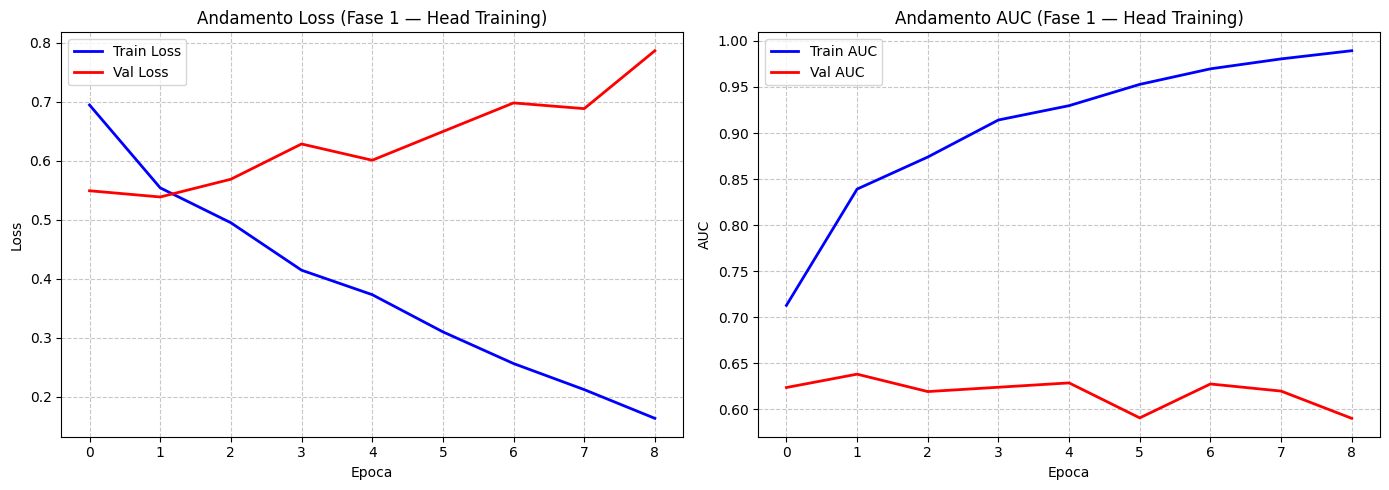

Analisi Overfitting - Fase 2 (Fine Tuning):
Grafico salvato in: ../experiments/exp_maxvit512_real_augmented/figures/training_history_fase2.png


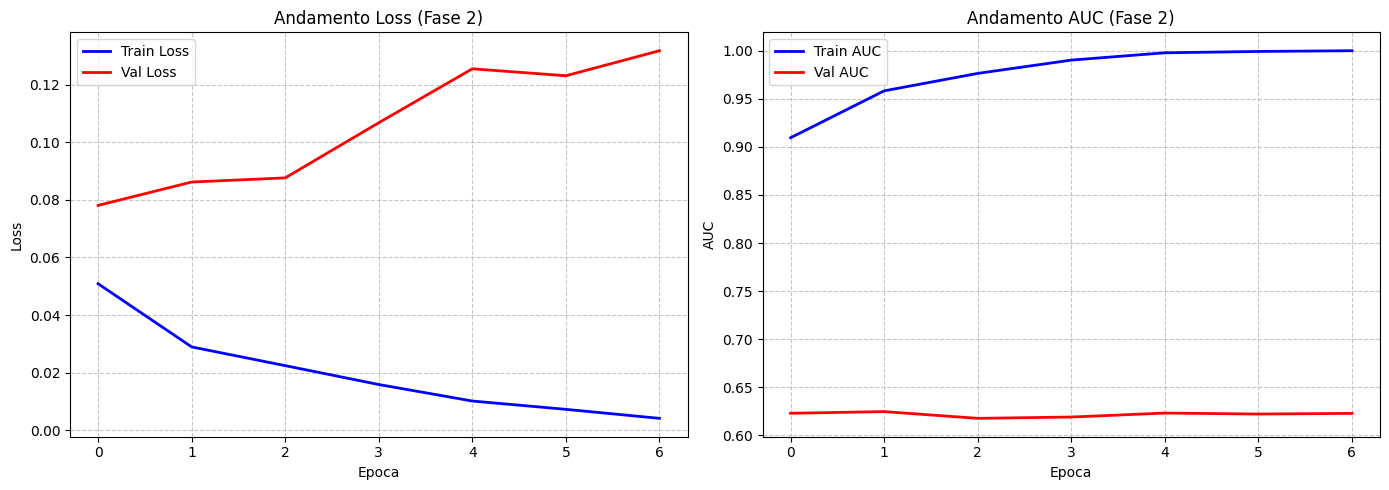

In [21]:
def plot_training_history(history, title_suffix="", save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_title(f'Andamento Loss {title_suffix}')
    ax1.set_xlabel('Epoca')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2.plot(history.history['auc'], label='Train AUC', color='blue', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red', linewidth=2)
    ax2.set_title(f'Andamento AUC {title_suffix}')
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('AUC')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Grafico salvato in: {save_path}")
    plt.show()

FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Analisi Overfitting - Fase 1 (Head Training):")
plot_training_history(
    history_phase1, "(Fase 1 — Head Training)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase1.png')
)

print("Analisi Overfitting - Fase 2 (Fine Tuning):")
plot_training_history(
    history_phase2, "(Fase 2)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase2.png')
)

#### Valutazione sul Test Set

La soglia di Youden viene calcolata sul validation set e congelata, poi applicata al test set
per evitare data leakage (stessa metodologia di `10`/`11`).

Soglia di Youden (VAL): 0.2663
AUC (test): 0.6103
              precision    recall  f1-score   support

        Sano       0.88      0.38      0.53       365
      Malato       0.19      0.74      0.31        73

    accuracy                           0.44       438
   macro avg       0.54      0.56      0.42       438
weighted avg       0.77      0.44      0.49       438

metriche salvate in test_metrics_maxvit512.json


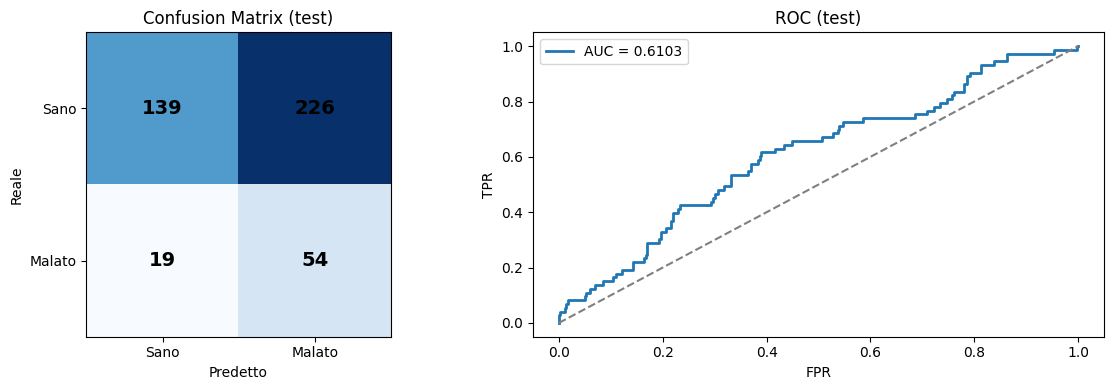

In [22]:
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'real_augmented_maxvit512_final_best.pt'), map_location=DEVICE))

val_true, val_prob = predict_probs(model, val_loader, DEVICE)
best_threshold = optimal_threshold_youden(val_true, val_prob)
print(f"Soglia di Youden (VAL): {best_threshold:.4f}")

test_true, test_prob = predict_probs(model, test_loader, DEVICE)
test_pred = (test_prob >= best_threshold).astype(int)

auc = roc_auc_score(test_true, test_prob)
report = classification_report(test_true, test_pred, target_names=['Sano', 'Malato'])
print(f"AUC (test): {auc:.4f}")
print(report)

metrics_dict = {
    'arch': 'MaxViT-Tiny-512', 'config': 'Real+Augmented', 'split': 'test',
    'threshold_youden_from_val': round(best_threshold, 4),
    'roc_auc': round(float(auc), 4),
    'accuracy': round(float((test_pred == test_true).mean()), 4),
    'precision_malato': round(float(precision_score(test_true, test_pred, pos_label=1, zero_division=0)), 4),
    'recall_malato': round(float(recall_score(test_true, test_pred, pos_label=1, zero_division=0)), 4),
    'f1_malato': round(float(f1_score(test_true, test_pred, pos_label=1, zero_division=0)), 4),
    'classification_report': report,
}
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
with open(os.path.join(OUTPUT_DIR, 'test_metrics_maxvit512.json'), 'w') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
print("metriche salvate in test_metrics_maxvit512.json")

cm = confusion_matrix(test_true, test_pred)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(cm, cmap='Blues')
ax[0].set_xticks([0, 1]); ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Sano', 'Malato']); ax[0].set_yticklabels(['Sano', 'Malato'])
ax[0].set_xlabel('Predetto'); ax[0].set_ylabel('Reale'); ax[0].set_title('Confusion Matrix (test)')
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')

fpr_t, tpr_t, _ = roc_curve(test_true, test_prob)
ax[1].plot(fpr_t, tpr_t, lw=2, label=f'AUC = {auc:.4f}')
ax[1].plot([0, 1], [0, 1], '--', color='gray')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].set_title('ROC (test)'); ax[1].legend()
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'test_confusion_roc_maxvit512.png'), dpi=150, bbox_inches='tight')
plt.show()

#### Valutazione con Bootstrap

Il test set è sbilanciato (365 sani / 73 malati): si usa un bootstrap bilanciato (ricampionamento
con reinserimento, N=1000 round) per stimare media e deviazione standard di ciascuna metrica,
esattamente come nei notebook `10`/`11`.

Accuracy   0.5599 +/- 0.0375
Precision  0.5443 +/- 0.0281
Recall     0.7412 +/- 0.0488
F1         0.6272 +/- 0.0324
ROC_AUC    0.6101 +/- 0.0444


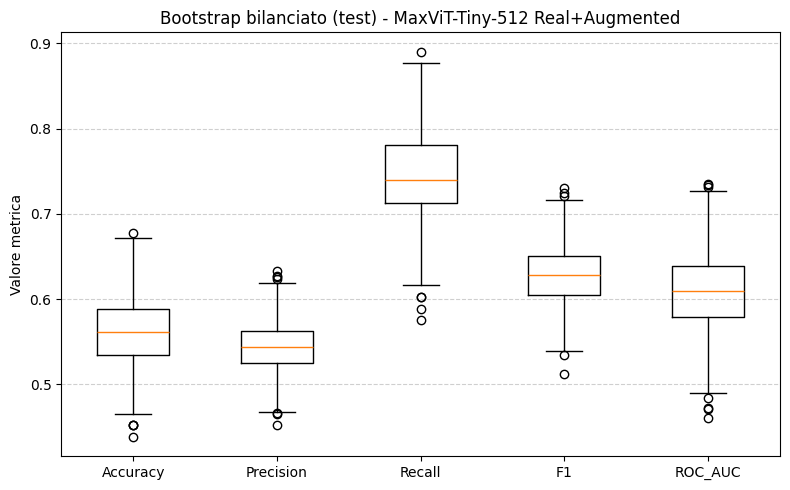

In [23]:
from maxvit_utils import bootstrap_balanced

boot = bootstrap_balanced(test_true, test_prob, best_threshold, n_rounds=1000, seed=SEED)
for k, v in boot.items():
    print("%-10s %.4f +/- %.4f" % (k, np.mean(v), np.std(v)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(list(boot.values()))
ax.set_xticklabels(list(boot.keys()))
ax.set_title(f'Bootstrap bilanciato (test) - MaxViT-Tiny-512 {config_name}')
ax.set_ylabel('Valore metrica')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'bootstrap_maxvit512.png'), dpi=150, bbox_inches='tight')
plt.show()